In [2]:
# !pip install medmnist torch torchvision torchmetrics

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import medmnist
from medmnist import INFO
import time

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load PneumoniaMNIST
data_flag = 'pneumoniamnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# Load datasets
train_dataset = DataClass(split='train', transform=transform, download=True)
test_dataset = DataClass(split='test', transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")


Using device: cpu


100%|██████████| 4.17M/4.17M [00:06<00:00, 599kB/s]


Train samples: 4708, Test samples: 624


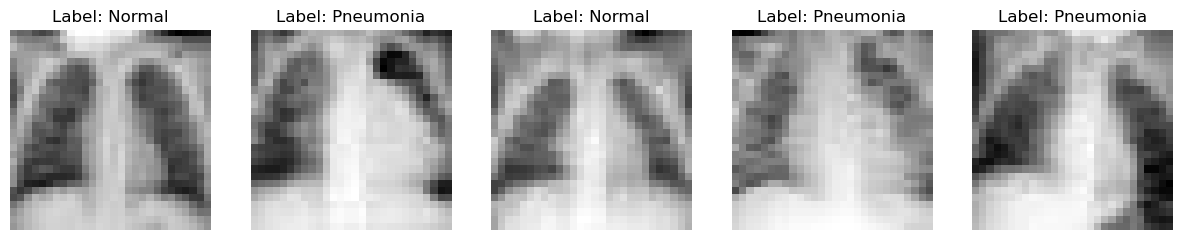

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_data(dataloader, num_images=5):
    images, labels = next(iter(dataloader))
    
    # PneumoniaMNIST labels: 0 = Normal, 1 = Pneumonia
    classes = ['Normal', 'Pneumonia']
    
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    for i in range(num_images):
        # Un-normalize the image for display (if normalized with mean 0.5, std 0.5)
        img = images[i].squeeze().numpy() * 0.5 + 0.5
        label = labels[i].squeeze().item()
        
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Label: {classes[label]}")
        axes[i].axis('off')
    plt.show()

visualize_data(train_loader)


In [3]:
class ImageTransformer(nn.Module):
    def __init__(self, input_size=28, num_classes=2, d_model=64, nhead=4, num_layers=2):
        super(ImageTransformer, self).__init__()
        self.embedding = nn.Linear(input_size, d_model)
        
        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x shape: (batch_size, 1, 28, 28) -> squeeze to (batch, seq_len=28, features=28)
        x = x.squeeze(1) 
        
        # Project features to d_model
        x = self.embedding(x)
        
        # Pass through transformer
        out = self.transformer_encoder(x)
        
        # Take the output of the last sequence step (or mean pool) for classification
        out = out[:, -1, :] 
        return self.fc(out)

transformer_model = ImageTransformer().to(device)


In [4]:
class ImageLSTM(nn.Module):
    def __init__(self, input_size=28, hidden_size=64, num_layers=2, num_classes=2):
        super(ImageLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch_size, 1, 28, 28) -> squeeze to (batch, seq_len=28, features=28)
        x = x.squeeze(1)
        
        out, (hn, cn) = self.lstm(x)
        
        # Take the hidden state of the last time step
        out = out[:, -1, :]
        return self.fc(out)

lstm_model = ImageLSTM().to(device)


--- Training Transformer ---
Epoch [1/5] - Loss: 0.1657 - Test Acc: 84.94%
Epoch [2/5] - Loss: 0.1391 - Test Acc: 86.70%
Epoch [3/5] - Loss: 0.1367 - Test Acc: 87.18%
Epoch [4/5] - Loss: 0.1356 - Test Acc: 87.18%
Epoch [5/5] - Loss: 0.1242 - Test Acc: 88.30%
Total Training Time: 174.27 seconds



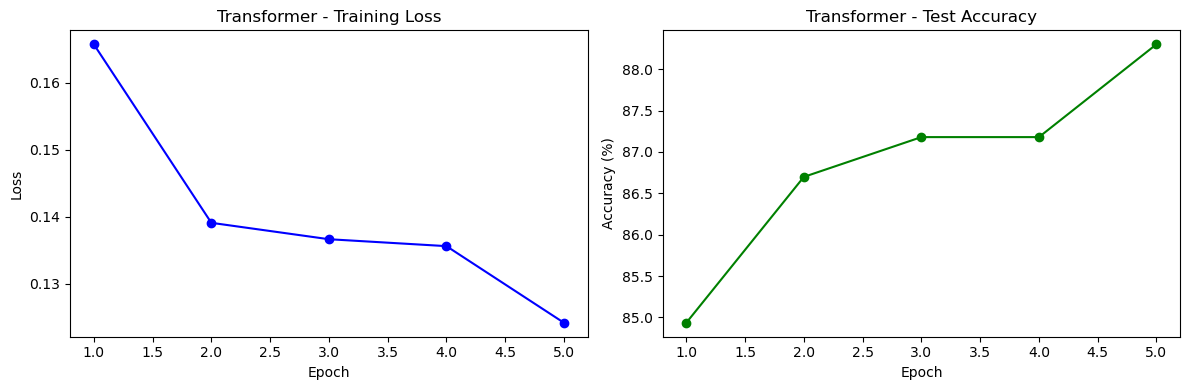

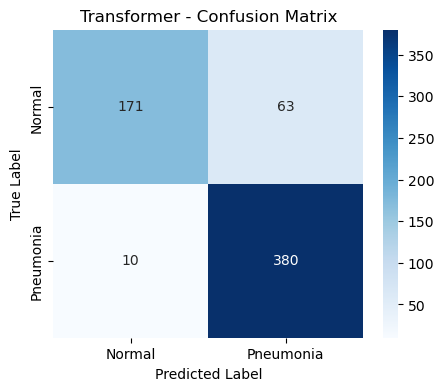

--- Training LSTM ---
Epoch [1/5] - Loss: 0.1310 - Test Acc: 88.14%
Epoch [2/5] - Loss: 0.1241 - Test Acc: 88.46%
Epoch [3/5] - Loss: 0.1201 - Test Acc: 86.54%
Epoch [4/5] - Loss: 0.1149 - Test Acc: 88.62%
Epoch [5/5] - Loss: 0.1050 - Test Acc: 87.50%
Total Training Time: 20.31 seconds



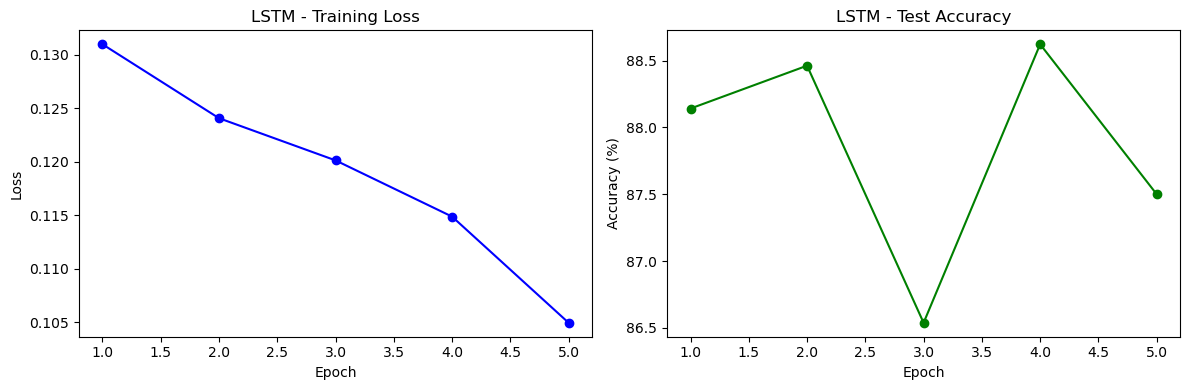

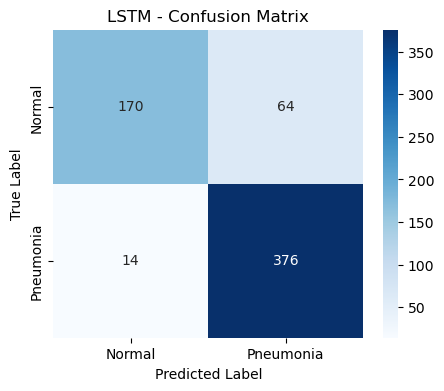

{'train_loss': [0.1309949451604405,
  0.12408633207952655,
  0.12014422938227654,
  0.11488918600150862,
  0.10496823590349506],
 'test_acc': [88.14102564102564,
  88.46153846153847,
  86.53846153846153,
  88.62179487179488,
  87.5]}

In [13]:

import torch.optim as optim
import seaborn as sns
from sklearn.metrics import confusion_matrix

def train_and_evaluate(model, name, train_loader, test_loader, device, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    model = model.to(device)
    
    history = {'train_loss': [], 'test_acc': []}
    
    print(f"--- Training {name} ---")
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.squeeze().long() 
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        epoch_loss = running_loss / len(train_loader)
        history['train_loss'].append(epoch_loss)
        
        # Evaluate after each epoch
        model.eval()
        correct, total = 0, 0
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels = labels.squeeze().long()
                
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
                # Save for confusion matrix on the last epoch
                if epoch == epochs - 1:
                    all_preds.extend(predicted.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())
                
        epoch_acc = 100 * correct / total
        history['test_acc'].append(epoch_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} - Test Acc: {epoch_acc:.2f}%")
        
    print(f"Total Training Time: {time.time() - start_time:.2f} seconds\n")
    
    # Plotting Learning Curves
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    ax[0].plot(range(1, epochs+1), history['train_loss'], marker='o', color='blue')
    ax[0].set_title(f'{name} - Training Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    
    ax[1].plot(range(1, epochs+1), history['test_acc'], marker='o', color='green')
    ax[1].set_title(f'{name} - Test Accuracy')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy (%)')
    
    plt.tight_layout()
    plt.show()
    
    # Plotting Confusion Matrix (Correlation of Predictions vs Actuals)
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Pneumonia'], 
                yticklabels=['Normal', 'Pneumonia'])
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return history


# Run comparison
train_and_evaluate(transformer_model, "Transformer",train_loader,test_loader,device)
train_and_evaluate(lstm_model, "LSTM",train_loader,test_loader,device)


--- Training Transformer ---
Epoch [1/5] - Loss: 0.2218 - Test Acc: 86.70%
Epoch [2/5] - Loss: 0.1796 - Test Acc: 83.97%
Epoch [3/5] - Loss: 0.1733 - Test Acc: 87.82%
Epoch [4/5] - Loss: 0.1630 - Test Acc: 89.90%
Epoch [5/5] - Loss: 0.1657 - Test Acc: 88.30%
Total Training Time: 184.90 seconds



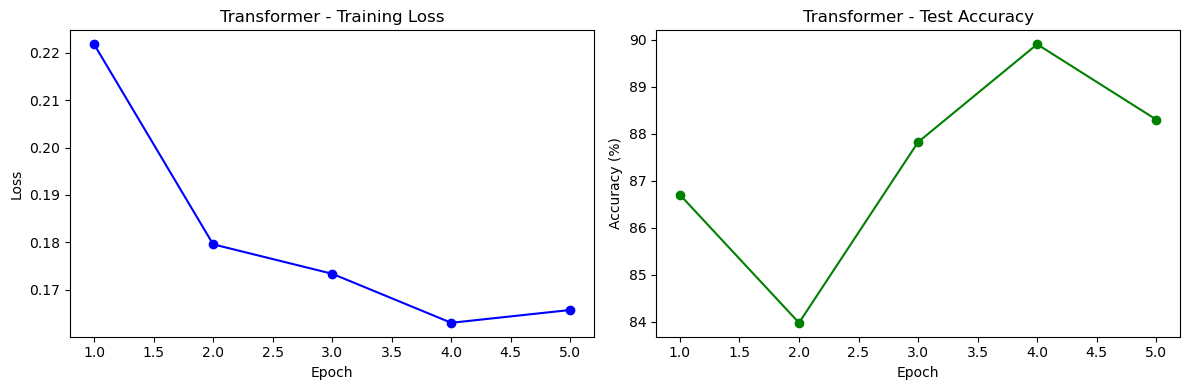

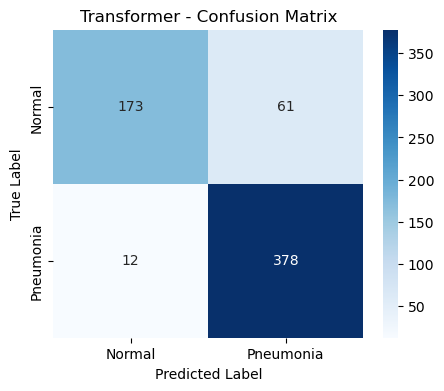

{'train_loss': [0.22183428372482997,
  0.17955319412253998,
  0.17333130951266032,
  0.16296889874580744,
  0.165678193742359],
 'test_acc': [86.69871794871794,
  83.97435897435898,
  87.82051282051282,
  89.90384615384616,
  88.30128205128206]}

In [15]:
from torchvision import transforms
import medmnist

# 1. Enhanced Augmentation for Training
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10), # Slight rotations
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# Test transform remains unchanged (no augmentation)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# Reload the datasets with the new transforms
train_dataset = medmnist.PneumoniaMNIST(split='train', transform=train_transform, download=True)
test_dataset = medmnist.PneumoniaMNIST(split='test', transform=test_transform, download=True)

train_loader_aug = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader_aug = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)
train_and_evaluate(transformer_model, "Transformer",train_loader_aug,test_loader_aug,device)


As we can see the best model is transfer model with augumentation to make the dataset larger for training.

---
# Discussion Questions 

Transformer-based models:

Advantages:
- Highly parallelizable (unlike RNNs), 
- capable of capturing long-range dependencies effectively, highly scalable
- achieves state-of-the-art performance across text, vision, and audio tasks.
Disadvantages: 
- requires massive datasets to outperform CNNs/RNNs from scratch
- computationally expensive
- **lacks strong inductive biases** why?
 Why Transformers “lack” these strong biases

A standard Transformer makes almost no assumptions about the data.

It does not look at images in local grids (like a CNN).
It does not process data step-by-step (like an RNN).
Instead, a Transformer looks at every piece of data all at once. By default, it treats an image or a sentence as an unordered “bag” of patches or words. It then uses the self-attention mechanism to calculate how every single piece of data relates to every other piece.

The Trade-off:

Because Transformers lack these built-in “hints” (inductive biases), they have to figure out the rules of geometry, sequence, and locality entirely from scratch. This is why they are data hungry—they require massive datasets to learn the rules that CNNs and RNNs are given by default. However, once given enough data, Transformers often perform better because they aren’t restricted by those assumptions and can find more complex, long-range relationships.

---
2. Why do they scale well with data and model size?

Transformers scale well because their self-attention mechanism and feed-forward networks consist of highly parallel matrix multiplications, which map perfectly to modern hardware (GPUs/TPUs). They do not suffer from the vanishing gradient bottleneck of deep RNNs, allowing architectures to be scaled to billions of parameters.
---
3. Why do they often require large computational resources compared to simpler models? 
I explain it at the end of Disadvatages of Transfer models.]
---
4. What is self-attention, and what problem does it solve?

Self-attention is a mechanism that allows a model to weigh the importance of different elements in an input sequence relative to one another to create a richer representation.t solves the information bottleneck and forgetting problem in standard RNNs/LSTMs. Instead of compressing a whole sequence into a single hidden state vector, self-attention allows the model to **“look back” at the entire sequence simultaneously** and directly draw connections between distant tokens/pixels, capturing long-range dependencies.

---
5. Why Attention Models Long-Range Dependencies Better Than RNNs

Problem with RNNs:
RNNs read sequences step-by-step.
Information must pass through many steps to reach far tokens.

Example:
word1 → word2 → word3 → ... → word100

If word1 is important for word100, the signal must travel through 98 steps.
During training, gradients shrink → the model forgets early information
(vanishing gradient problem).

How Attention Fixes This:
Attention lets every token directly look at every other token.

word100 can attend directly to word1.

---
6. What Multi-Head Attention Is and Why It Helps

Basic Attention:
One attention mechanism learns one type of relationship between words.

Multi-Head Attention:
The model runs several attention mechanisms in parallel ("heads").

Process:
1. Split Q, K, V into multiple smaller spaces
2. Each head computes attention independently
3. Combine (concatenate) the results

Why this helps:
Different heads can learn different relationships at the same time.

Example in a sentence:
"The dog that chased the cat was loud"

Head 1 → focus on subject–verb relation
Head 2 → focus on noun–adjective relation
Head 3 → focus on long-distance grammar


---
3. The Role of Positional Encoding

Problem:
Transformers process all words at the same time,
so they don't naturally know the order of words.

Example:
"The dog bit the man"
"The man bit the dog"

Without position information, these look identical.

Solution: Positional Encoding

Before entering the Transformer:
embedding_with_position = word_embedding + positional_encoding

Each position gets a unique mathematical pattern
(often using sine and cosine functions).

Result:
The model can understand:
- which word comes first
- which word comes later
- distances between words






